baseline = 0.200
     Feat13-RF  (feat): AP = 0.944
      Feat4-RF  (feat): AP = 0.941
     Feat13-GB  (feat): AP = 0.932
      Feat4-GB  (feat): AP = 0.927
    SeqMore-RF  (seq): AP = 0.916
    SeqMore-GB  (seq): AP = 0.912
    SeqMono-RF  (seq): AP = 0.910
    SeqMono-GB  (seq): AP = 0.907


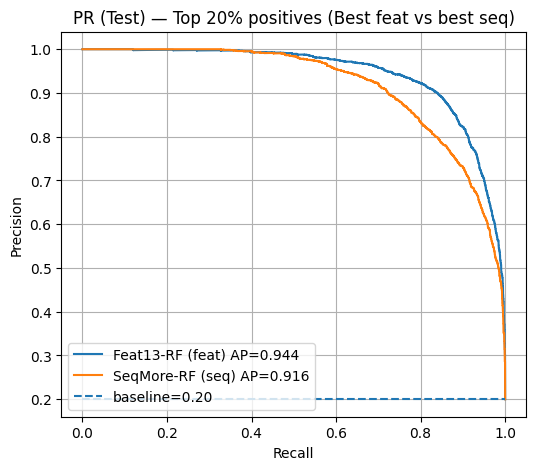

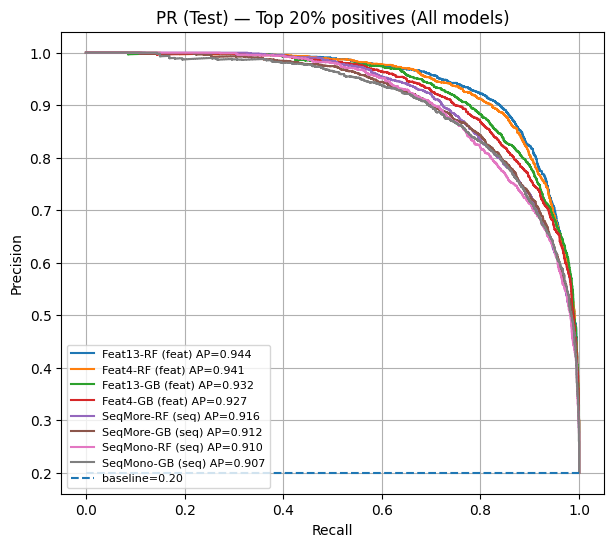

In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

POS_FRAC = 0.20  # top 20% positives

# ---- 1) List your 8 models here ----
# type must be "seq" or "feat" (or any labels you like, used for picking best per group)
MODELS = [
  

    # ---- Feature models ----
    {"name": "Feat4-GB",   "path": "shape_booster4_model.joblib",   "type": "feat"},
    {"name": "Feat4-RF",   "path": "shape_rf_model_4.joblib",        "type": "feat"},
    {"name": "Feat13-GB",  "path": "shape_booster13model.joblib",  "type": "feat"},
    {"name": "Feat13-RF",  "path": "shape_rf_model13.joblib",       "type": "feat"},

    # ---- Sequence models ----
    {"name": "SeqMono-GB", "path": "seq_boost_model76.joblib",      "type": "seq"},
    {"name": "SeqMore-GB", "path": "seq_boost_model.joblib",         "type": "seq"},
    {"name": "SeqMono-RF", "path": "seq76_rf_model.joblib",         "type": "seq"},
    {"name": "SeqMore-RF", "path": "seq_rf_model.joblib",            "type": "seq"},

]

import numpy as np

def get_arrays(bundle):
    Y_TRUE_KEY = "y_true_te"
    Y_PRED_KEYS = ("y_pred_te", "y_pred_te_seq")

    if Y_TRUE_KEY not in bundle:
        raise KeyError(f"Bundle missing '{Y_TRUE_KEY}'. Keys: {list(bundle.keys())}")

    for k in Y_PRED_KEYS:
        if k in bundle:
            y_true = np.asarray(bundle[Y_TRUE_KEY]).ravel()
            y_pred = np.asarray(bundle[k]).ravel()
            return y_true, y_pred

    raise KeyError(
        f"Bundle missing any of {Y_PRED_KEYS}. Keys: {list(bundle.keys())}"
    )
def load_bundle(path: str) -> dict:
    return joblib.load(path)





# ---- 2) Load all models, ensure same y_true across them ----
results = []
yte_ref = None

for m in MODELS:
    b = load_bundle(m["path"])
    yte, yhat = get_arrays(b)

    if yte_ref is None:
        yte_ref = yte
    else:
        # If your bundles store identical y_true, this will pass.
        # If not, you need to align by IDs (then tell me what key contains IDs).
        if len(yte) != len(yte_ref) or not np.allclose(yte, yte_ref):
            raise ValueError(
                f"y_true mismatch for model '{m['name']}' ({m['path']}). "
                "All models must share the same test labels in the same order."
            )

    results.append({**m, "y_true": yte, "y_pred": yhat})

# ---- 3) Build binary labels for Top POS_FRAC positives ----
cut = np.quantile(yte_ref, 1 - POS_FRAC)
y_bin = (yte_ref >= cut).astype(int)

# ---- 4) Compute PR + AP for each model ----
for r in results:
    ap = average_precision_score(y_bin, r["y_pred"])
    p, rec, _ = precision_recall_curve(y_bin, r["y_pred"])
    r["ap"] = ap
    r["precision"] = p
    r["recall"] = rec

# ---- 5) Pick best sequence + best feature ----
best_seq  = max((r for r in results if r["type"] == "seq"),  key=lambda x: x["ap"], default=None)
best_feat = max((r for r in results if r["type"] == "feat"), key=lambda x: x["ap"], default=None)

print(f"baseline = {POS_FRAC:.3f}")
for r in sorted(results, key=lambda x: x["ap"], reverse=True):
    print(f"{r['name']:>14}  ({r['type']}): AP = {r['ap']:.3f}")

# ---- 6a) Plot: Best feature vs best sequence ----
plt.figure(figsize=(6, 5))

if best_feat is not None:
    plt.step(best_feat["recall"], best_feat["precision"], where="post",
             label=f"{best_feat['name']} (feat) AP={best_feat['ap']:.3f}")
if best_seq is not None:
    plt.step(best_seq["recall"], best_seq["precision"], where="post",
             label=f"{best_seq['name']} (seq) AP={best_seq['ap']:.3f}")

plt.hlines(POS_FRAC, 0, 1, linestyles="dashed", label=f"baseline={POS_FRAC:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR (Test) — Top {int(POS_FRAC*100)}% positives (Best feat vs best seq)")
plt.legend()
plt.grid(True)
plt.show()



# ---- 6b) Plot: All 8 models in one image ----
plt.figure(figsize=(7, 6))
for r in sorted(results, key=lambda x: x["ap"], reverse=True):
    plt.step(r["recall"], r["precision"], where="post",
             label=f"{r['name']} ({r['type']}) AP={r['ap']:.3f}")

plt.hlines(POS_FRAC, 0, 1, linestyles="dashed", label=f"baseline={POS_FRAC:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR (Test) — Top {int(POS_FRAC*100)}% positives (All models)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [8]:
import joblib
import pandas as pd
import numpy as np

models = [
    {"name": "Feat4-GB",   "path": "shape_booster4_model.joblib"},
    {"name": "Feat4-RF",   "path": "shape_rf_model_4.joblib"},
    {"name": "Feat13-GB",  "path": "shape_booster13model.joblib"},
    {"name": "Feat13-RF",  "path": "shape_rf_model13.joblib"},
    {"name": "SeqMono-GB", "path": "seq_boost_model76.joblib"},
    {"name": "SeqMore-GB", "path": "seq_boost_model.joblib"},
    {"name": "SeqMono-RF", "path": "seq76_rf_model.joblib"},
    {"name": "SeqMore-RF", "path": "seq_rf_model.joblib"},
]

def describe_object(obj):
    if isinstance(obj, pd.DataFrame):
        return f"DataFrame shape={obj.shape}"
    if isinstance(obj, pd.Series):
        return f"Series shape={obj.shape}"
    if isinstance(obj, np.ndarray):
        return f"ndarray shape={obj.shape}"
    if isinstance(obj, list):
        return f"list len={len(obj)}"
    return type(obj).__name__

for cfg in models:
    print(f"\n===== {cfg['name']} =====")
    bundle = joblib.load(cfg["path"])

    print("Top-level type:", type(bundle).__name__)

    if isinstance(bundle, dict):
        print("Keys:", list(bundle.keys()))
        for k, v in bundle.items():
            print(f"  {k}: {describe_object(v)}")

        # try common names that might contain saved training data
        for candidate in ["X_train", "X", "train_X", "x_train", "features", "X_test", "feature_columns"]:
            if candidate in bundle:
                print(f"\nFound possible '{candidate}':")
                print(bundle[candidate])
    else:
        print("This file is not a dict bundle; direct model object only.")
        if hasattr(bundle, "feature_names_in_"):
            print("feature_names_in_:", list(bundle.feature_names_in_))
        if hasattr(bundle, "n_features_in_"):
            print("n_features_in_:", bundle.n_features_in_)


===== Feat4-GB =====
Top-level type: dict
Keys: ['version', 'trained_at', 'label_col', 'families', 'keep_window', 'exclude', 'rf_params', 'seed', 'feature_columns', 'imputer', 'calibrator', 'model', 'y_true_te', 'y_pred_te']
  version: str
  trained_at: str
  label_col: str
  families: list len=4
  keep_window: tuple
  exclude: tuple
  rf_params: dict
  seed: int
  feature_columns: list len=76
  imputer: SimpleImputer
  calibrator: NoneType
  model: HistGradientBoostingRegressor
  y_true_te: ndarray shape=(19469,)
  y_pred_te: ndarray shape=(19469,)

Found possible 'feature_columns':
['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'ProT_5', 'ProT_6', 'ProT_7', 'ProT_8', 'ProT_9', 'ProT_10', 'ProT_11', 'ProT_12', 'ProT_13', 'ProT_14', 'ProT_15', 'ProT_16', 'ProT_17', 'ProT_18', 'ProT_19', 'ProT_20', 'ProT_21', 'ProT_22', 'ProT_23', 'Roll_5', 'Roll_6'

In [10]:
import joblib, numpy as np

def debug_bundle(path):
    b = joblib.load(path)
    y = np.asarray(b["y_true_te"]).ravel()
    # pick pred key:
    pred_key = "y_pred_te" if "y_pred_te" in b else "y_pred_te_seq"
    p = np.asarray(b[pred_key]).ravel()
    print("\n", path)
    print("pred_key:", pred_key)
    print("len y, len p:", len(y), len(p))
    print("pred min/max:", float(np.min(p)), float(np.max(p)))
    print("corr(y, p):", float(np.corrcoef(y, p)[0,1]))
    print("allclose(y,p):", np.allclose(y, p))
    print("allclose(y,rank(p)):", np.allclose(y, np.argsort(np.argsort(p))))
    
debug_bundle("shape_booster4_model.joblib")
debug_bundle("shape_booster13_model.joblib")


 shape_booster4_model.joblib
pred_key: y_pred_te
len y, len p: 19469 19469
pred min/max: 1.2406431005120242 3.0786924233366704
corr(y, p): 0.9243413085323998
allclose(y,p): False
allclose(y,rank(p)): False

 shape_booster13_model.joblib
pred_key: y_pred_te
len y, len p: 19469 19469
pred min/max: 1.240814903232455 3.083087262167255
corr(y, p): 0.9272687113082372
allclose(y,p): False
allclose(y,rank(p)): False


Top positives fraction: 0.200010272741281
Bottom positives fraction: 0.200010272741281
Median positives fraction: 0.5000256818532025
cut_top: 2.3132253652 cut_bottom: 1.766006771 median: 2.031031587
Feat4-GB AP bottom raw: 0.10945343917924455 AP bottom flipped: 0.8250128416718516
Feat4-RF AP bottom raw: 0.10986056375293544 AP bottom flipped: 0.8046806671450099
Feat13-GB AP bottom raw: 0.10933300057144227 AP bottom flipped: 0.8322510901481853
Feat13-RF AP bottom raw: 0.10977468244071253 AP bottom flipped: 0.8096192762141101
SeqMono-GB AP bottom raw: 0.10961979184217616 AP bottom flipped: 0.8145728319127498
SeqMore-GB AP bottom raw: 0.1096712082534854 AP bottom flipped: 0.8112021160231182
SeqMono-RF AP bottom raw: 0.1100889473405919 AP bottom flipped: 0.7930106612472247
SeqMore-RF AP bottom raw: 0.11022551154560584 AP bottom flipped: 0.7873278204337751

=== AUPRC (Top 20%) === baseline=0.200
 Feat13-RF (feat)  AP_top=0.944
  Feat4-RF (feat)  AP_top=0.941
 Feat13-GB (feat)  AP_top=0.932
 

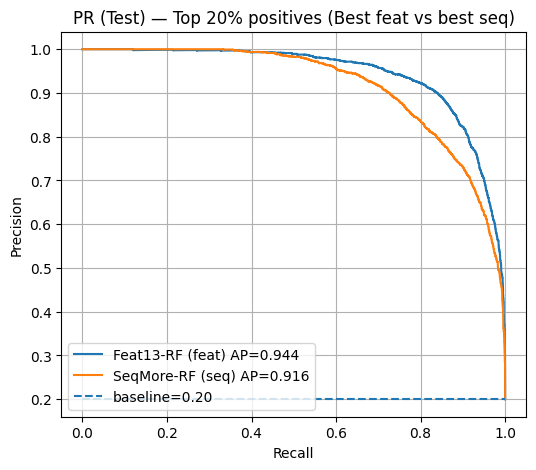

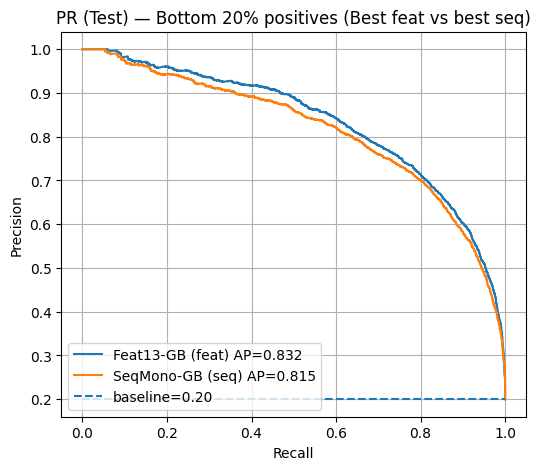

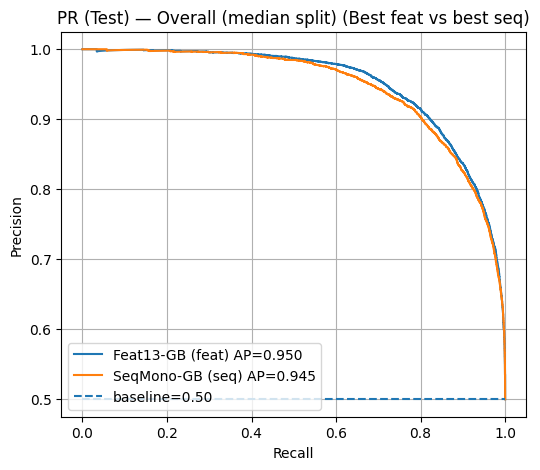

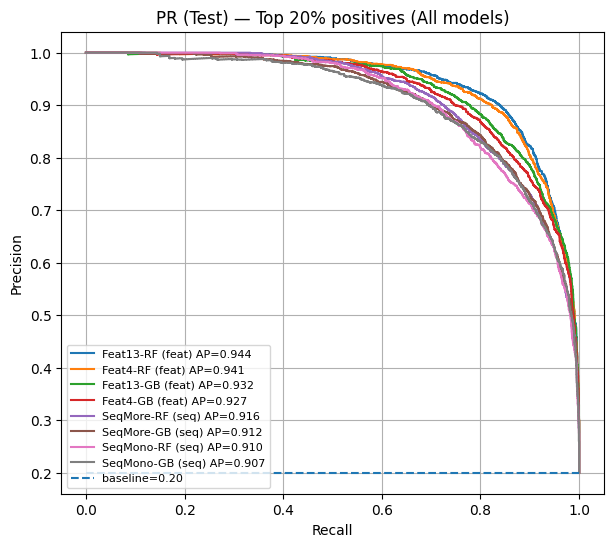

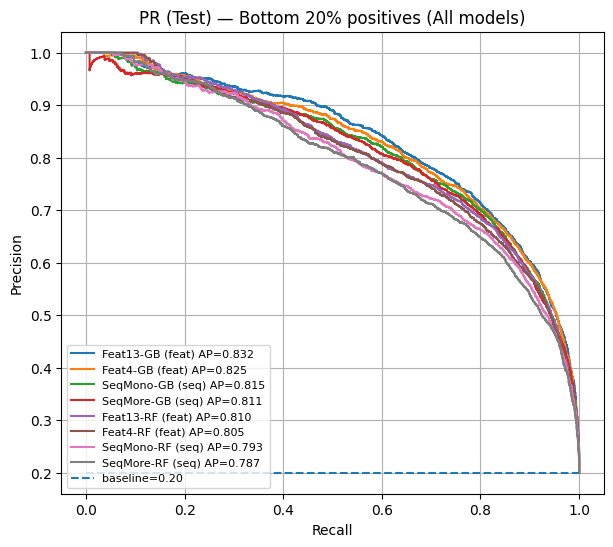

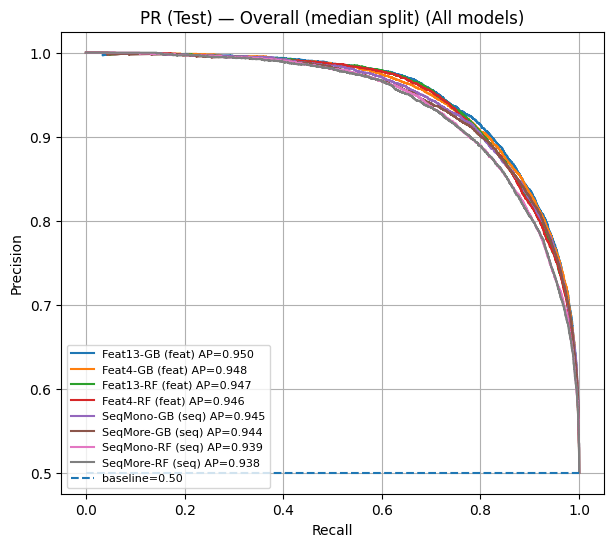

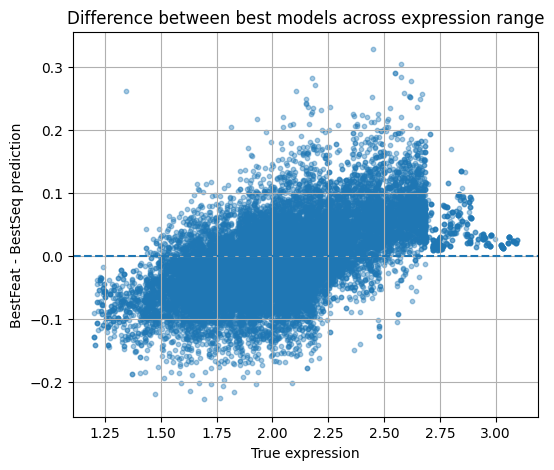


=== Best-model disagreement diagnostics (Top winners) ===
Mean diff: -0.00328607592107069
Std  diff: 0.06136993008017587
Corr(true, diff): 0.5892988443860578
Corr(pred_feat, pred_seq): 0.9824964917457641


In [6]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

POS_FRAC = 0.20  # top/bottom 20%

MODELS = [
    # ---- Feature models ----
    {"name": "Feat4-GB",   "path": "shape_booster4_model.joblib",   "type": "feat"},
    {"name": "Feat4-RF",   "path": "shape_rf_model_4.joblib",       "type": "feat"},
    {"name": "Feat13-GB",  "path": "shape_booster13model.joblib",  "type": "feat"},
    {"name": "Feat13-RF",  "path": "shape_rf_model13.joblib",       "type": "feat"},

    # ---- Sequence models ----
    {"name": "SeqMono-GB", "path": "seq_boost_model76.joblib",      "type": "seq"},
    {"name": "SeqMore-GB", "path": "seq_boost_model.joblib",        "type": "seq"},
    {"name": "SeqMono-RF", "path": "seq76_rf_model.joblib",         "type": "seq"},
    {"name": "SeqMore-RF", "path": "seq_rf_model.joblib",           "type": "seq"},
]

def load_bundle(path: str) -> dict:
    return joblib.load(path)

def get_arrays(bundle):
    Y_TRUE_KEY = "y_true_te"
    Y_PRED_KEYS = ("y_pred_te", "y_pred_te_seq")

    if Y_TRUE_KEY not in bundle:
        raise KeyError(f"Bundle missing '{Y_TRUE_KEY}'. Keys: {list(bundle.keys())}")

    for k in Y_PRED_KEYS:
        if k in bundle:
            y_true = np.asarray(bundle[Y_TRUE_KEY]).ravel()
            y_pred = np.asarray(bundle[k]).ravel()
            return y_true, y_pred, k

    raise KeyError(f"Bundle missing any of {Y_PRED_KEYS}. Keys: {list(bundle.keys())}")

def compute_pr_ap(y_bin, scores):
    ap = average_precision_score(y_bin, scores)
    p, r, _ = precision_recall_curve(y_bin, scores)
    return ap, p, r

def pick_best(results, model_type, ap_key):
    candidates = [x for x in results if x["type"] == model_type]
    return max(candidates, key=lambda x: x[ap_key]) if candidates else None

def _save_and_show(savepath=None, dpi=600):
    """Save BEFORE show (show may clear/close depending on backend)."""
    fig = plt.gcf()
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    plt.savefig(
    "3.pdf",
    bbox_inches="tight"
)
    plt.show()
    plt.close(fig)

def plot_best_vs_best(best_feat, best_seq, ap_key, title, baseline, savepath=None):
    plt.figure(figsize=(6, 5))

    if best_feat is not None:
        plt.step(best_feat[f"recall_{ap_key}"], best_feat[f"precision_{ap_key}"], where="post",
                 label=f"{best_feat['name']} (feat) AP={best_feat[ap_key]:.3f}")
    if best_seq is not None:
        plt.step(best_seq[f"recall_{ap_key}"], best_seq[f"precision_{ap_key}"], where="post",
                 label=f"{best_seq['name']} (seq) AP={best_seq[ap_key]:.3f}")

    plt.hlines(baseline, 0, 1, linestyles="dashed", label=f"baseline={baseline:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(
    " Precition call.pdf",
    bbox_inches="tight"
)

    _save_and_show(savepath=savepath)

def plot_all_models(results, ap_key, title, baseline, savepath=None):
    plt.figure(figsize=(7, 6))

    for r in sorted(results, key=lambda x: x[ap_key], reverse=True):
        plt.step(r[f"recall_{ap_key}"], r[f"precision_{ap_key}"], where="post",
                 label=f"{r['name']} ({r['type']}) AP={r[ap_key]:.3f}")

    plt.hlines(baseline, 0, 1, linestyles="dashed", label=f"baseline={baseline:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.savefig(
    "1.pdf",
    bbox_inches="tight"
)
    _save_and_show(savepath=savepath)

# -----------------------------
# 1) Load models and validate y_true identical
# -----------------------------
results = []
yte_ref = None

for m in MODELS:
    b = load_bundle(m["path"])
    yte, yhat, used_key = get_arrays(b)

    if yte_ref is None:
        yte_ref = yte
    else:
        if len(yte) != len(yte_ref) or not np.allclose(yte, yte_ref):
            raise ValueError(
                f"y_true mismatch for model '{m['name']}' ({m['path']}). "
                "All models must share the same test labels in the same order."
            )

    results.append({**m, "y_true": yte, "y_pred": yhat, "pred_key": used_key})

# -----------------------------
# 2) Build binary labels for TOP / BOTTOM / MEDIAN
# -----------------------------
cut_top = np.quantile(yte_ref, 1 - POS_FRAC)
y_bin_top = (yte_ref >= cut_top).astype(int)
baseline_top = POS_FRAC

cut_bottom = np.quantile(yte_ref, POS_FRAC)
y_bin_bottom = (yte_ref <= cut_bottom).astype(int)
baseline_bottom = POS_FRAC

y_bin_median = (yte_ref >= np.median(yte_ref)).astype(int)
baseline_median = float(np.mean(y_bin_median))  # ~0.50

# (optional sanity prints)
print("Top positives fraction:", y_bin_top.mean())
print("Bottom positives fraction:", y_bin_bottom.mean())
print("Median positives fraction:", y_bin_median.mean())
print("cut_top:", cut_top, "cut_bottom:", cut_bottom, "median:", np.median(yte_ref))

# -----------------------------
# 3) Compute PR/AP for each model (TOP/BOTTOM/MEDIAN)
# -----------------------------
for r in results:
    # TOP: positives are HIGH y_true, so use y_pred directly
    ap_top, p_top, rec_top = compute_pr_ap(y_bin_top, r["y_pred"])
    r["ap_top"] = ap_top
    r["precision_ap_top"] = p_top
    r["recall_ap_top"] = rec_top

    # BOTTOM: positives are LOW y_true, so flip score direction
    ap_bottom, p_bottom, rec_bottom = compute_pr_ap(y_bin_bottom, -r["y_pred"])
    r["ap_bottom"] = ap_bottom
    r["precision_ap_bottom"] = p_bottom
    r["recall_ap_bottom"] = rec_bottom

    # MEDIAN: positives are HIGH half, so use y_pred directly
    ap_median, p_med, rec_med = compute_pr_ap(y_bin_median, r["y_pred"])
    r["ap_median"] = ap_median
    r["precision_ap_median"] = p_med
    r["recall_ap_median"] = rec_med

# (optional debug: confirm flip helped)
for r in results:
    ap_raw, _, _ = compute_pr_ap(y_bin_bottom, r["y_pred"])
    ap_flip, _, _ = compute_pr_ap(y_bin_bottom, -r["y_pred"])
    print(r["name"], "AP bottom raw:", ap_raw, "AP bottom flipped:", ap_flip)
    cut_bottom = np.quantile(yte_ref, POS_FRAC)
baseline_bottom = POS_FRAC
y_bin_bottom = (yte_ref <= cut_bottom).astype(int)
# -----------------------------
# 3) Compute PR/AP for each model (TOP/BOTTOM/MEDIAN)
# -----------------------------
for r in results:
    ap_top, p_top, rec_top = compute_pr_ap(y_bin_top, r["y_pred"])
    r["ap_top"] = ap_top
    r["precision_ap_top"] = p_top
    r["recall_ap_top"] = rec_top

    # THIS LINE MUST USE -r["y_pred"]
    ap_bottom, p_bottom, rec_bottom = compute_pr_ap(y_bin_bottom, -r["y_pred"])
    r["ap_bottom"] = ap_bottom
    r["precision_ap_bottom"] = p_bottom
    r["recall_ap_bottom"] = rec_bottom

    ap_median, p_med, rec_med = compute_pr_ap(y_bin_median, r["y_pred"])
    r["ap_median"] = ap_median
    r["precision_ap_median"] = p_med
    r["recall_ap_median"] = rec_med

# -----------------------------
# 4) Print numbers
# -----------------------------
print(f"\n=== AUPRC (Top {int(POS_FRAC*100)}%) === baseline={baseline_top:.3f}")
for r in sorted(results, key=lambda x: x["ap_top"], reverse=True):
    print(f"{r['name']:>10} ({r['type']})  AP_top={r['ap_top']:.3f}")

print(f"\n=== AUPRC (Bottom {int(POS_FRAC*100)}%) === baseline={baseline_bottom:.3f}")
for r in sorted(results, key=lambda x: x["ap_bottom"], reverse=True):
    print(f"{r['name']:>10} ({r['type']})  AP_bottom={r['ap_bottom']:.3f}")

print(f"\n=== AUPRC (Median split overall) === baseline={baseline_median:.3f}")
for r in sorted(results, key=lambda x: x["ap_median"], reverse=True):
    print(f"{r['name']:>10} ({r['type']})  AP_median={r['ap_median']:.3f}")

# -----------------------------
# 5) Best vs best plots (clean, for main text)
# -----------------------------
plot_best_vs_best(
    pick_best(results, "feat", "ap_top"),
    pick_best(results, "seq",  "ap_top"),
    ap_key="ap_top",
    title=f"PR (Test) — Top {int(POS_FRAC*100)}% positives (Best feat vs best seq)",
    baseline=baseline_top,
    savepath="top_20_best.pdf"
    
)

plot_best_vs_best(
    pick_best(results, "feat", "ap_bottom"),
    pick_best(results, "seq",  "ap_bottom"),
    ap_key="ap_bottom",
    
    title=f"PR (Test) — Bottom {int(POS_FRAC*100)}% positives (Best feat vs best seq)",
    baseline=baseline_bottom,
    savepath="bottom_20_best.pdf"
)

plot_best_vs_best(
    pick_best(results, "feat", "ap_median"),
    pick_best(results, "seq",  "ap_median"),
    ap_key="ap_median",
    title="PR (Test) — Overall (median split) (Best feat vs best seq)",
    baseline=baseline_median,
    savepath="median_best.pdf"
)

# -----------------------------
# 6) Supplementary plots (all models)
# -----------------------------
plot_all_models(
    results, ap_key="ap_top",
    title=f"PR (Test) — Top {int(POS_FRAC*100)}% positives (All models)",
    baseline=baseline_top,
    savepath="top_20_all.pdf"
)

plot_all_models(
    results, ap_key="ap_bottom",
    title=f"PR (Test) — Bottom {int(POS_FRAC*100)}% positives (All models)",
    baseline=baseline_bottom,
    savepath="bottom_20_all.pdf"
)

plot_all_models(
    results, ap_key="ap_median",
    title="PR (Test) — Overall (median split) (All models)",
    baseline=baseline_median,
    savepath="median_all.pdf"
)

# -----------------------------
# 7) Optional: disagreement plot for TOP winners
# -----------------------------
best_feat_top = pick_best(results, "feat", "ap_top")
best_seq_top  = pick_best(results, "seq",  "ap_top")

if best_feat_top is not None and best_seq_top is not None:
    diff = best_feat_top["y_pred"] - best_seq_top["y_pred"]
    plt.figure(figsize=(6, 5))
    plt.scatter(yte_ref, diff, s=10, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("True expression")
    plt.ylabel("BestFeat - BestSeq prediction")
    plt.title("Difference between best models across expression range")
    plt.grid(True)
    plt.savefig(
    "2.pdf",
    bbox_inches="tight"
) 
    _save_and_show(savepath="best_model_disagreement.png")

    print("\n=== Best-model disagreement diagnostics (Top winners) ===")
    print("Mean diff:", float(np.mean(diff)))
    print("Std  diff:", float(np.std(diff)))
    print("Corr(true, diff):", float(np.corrcoef(yte_ref, diff)[0, 1]))
    print("Corr(pred_feat, pred_seq):", float(np.corrcoef(best_feat_top["y_pred"], best_seq_top["y_pred"])[0, 1]))